In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

print('All libraries loaded successfully!')

All libraries loaded successfully!


In [2]:
# Load Dataset

ratings = pd.read_csv("data/ratings.csv")
movies = pd.read_csv("data/movies.csv")
tags = pd.read_csv("data/tags.csv")
links = pd.read_csv("data/links.csv")

In [3]:
print("Ratings Shape:", ratings.shape)
print("Movies Shape:", movies.shape)
print("Tags Shape:", tags.shape)
print("Links Shape:", links.shape)

print("\nRatings Sample:")
print(ratings.head())

print("\nMovies Sample:")
print(movies.head())

Ratings Shape: (100836, 4)
Movies Shape: (9742, 3)
Tags Shape: (3683, 4)
Links Shape: (9742, 3)

Ratings Sample:
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

Movies Sample:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [4]:
# Remove duplicates
ratings.drop_duplicates(inplace=True)
movies.drop_duplicates(inplace=True)
tags.drop_duplicates(inplace=True)
links.drop_duplicates(inplace=True)

# Fix dtypes
ratings['userId']  = ratings['userId'].astype(int)
ratings['movieId'] = ratings['movieId'].astype(int)
movies['movieId']  = movies['movieId'].astype(int)

# Rename & convert timestamps
tags    = tags.rename(columns={'timestamp': 'timestamp_tags'})
ratings = ratings.rename(columns={'timestamp': 'timestamp_rate'})
ratings['timestamp_rate'] = pd.to_datetime(ratings['timestamp_rate'], unit='s')
tags['timestamp_tags']    = pd.to_datetime(tags['timestamp_tags'],    unit='s')

# Fill missing tmdbId
links['tmdbId'] = links['tmdbId'].fillna(0).astype(int)

print('Cleaning done.')

Cleaning done.


In [5]:
# Merge Datasets

movie_data = ratings.merge(
    movies,
    on='movieId',
    how='left'
)

movie_data = movie_data.merge(
    links,
    on='movieId',
    how='left'
)

In [6]:
# Split genres into list
movie_data['genres'] = movie_data['genres'].apply(
    lambda x: x.split('|')
)

In [7]:
# Remove rows with missing tmdbId
movie_data = movie_data.dropna(subset=['tmdbId'])

# Convert tmdbId to integer
movie_data['tmdbId'] = movie_data['tmdbId'].astype(int)

# Verify
print("\nMissing tmdbId values after removing:")
print(movie_data['tmdbId'].isnull().sum())

print("\nUpdated Dataset Shape:")
print(movie_data.shape)


Missing tmdbId values after removing:
0

Updated Dataset Shape:
(100836, 8)


In [8]:
most_rated = movie_data.groupby('title')['rating'].count()

most_rated = most_rated.sort_values(ascending=False)

print("\nMost Rated Movies:")
print(most_rated.head(10))



Most Rated Movies:
title
Forrest Gump (1994)                          329
Shawshank Redemption, The (1994)             317
Pulp Fiction (1994)                          307
Silence of the Lambs, The (1991)             279
Matrix, The (1999)                           278
Star Wars: Episode IV - A New Hope (1977)    251
Jurassic Park (1993)                         238
Braveheart (1995)                            237
Terminator 2: Judgment Day (1991)            224
Schindler's List (1993)                      220
Name: rating, dtype: int64


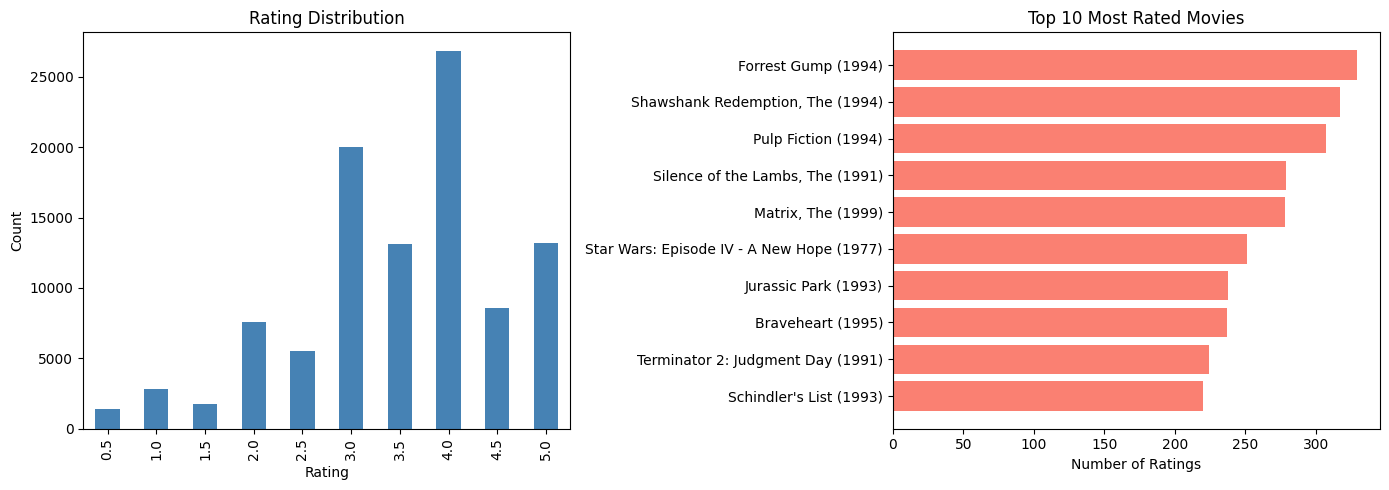

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

top_movies = ratings['movieId'].value_counts().head(10)
top_titles = movies.set_index('movieId').loc[top_movies.index, 'title']
axes[1].barh(top_titles.values[::-1], top_movies.values[::-1], color='salmon')
axes[1].set_title('Top 10 Most Rated Movies')
axes[1].set_xlabel('Number of Ratings')

plt.tight_layout()
plt.show()

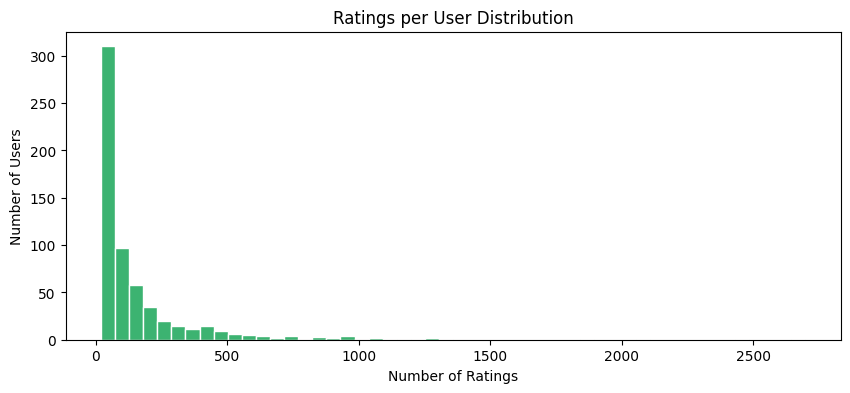

Average ratings per user: 165.3


In [10]:
ratings_per_user = ratings.groupby('userId')['rating'].count()
plt.figure(figsize=(10, 4))
plt.hist(ratings_per_user, bins=50, color='mediumseagreen', edgecolor='white')
plt.title('Ratings per User Distribution')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.show()
print(f'Average ratings per user: {ratings_per_user.mean():.1f}')

In [11]:
#===================================
#2-Content-Based Filtering Module:
#في الـ Content-Based Filtering أنت بترشح أفلام بناءً على محتوى الفيلم نفسه مش سلوك المستخدمين.
#===================================

In [12]:
#group tags by movieId
tags_grouped = tags.groupby('movieId')['tag'].apply(lambda x: " ".join(x.astype(str)))
print("\nTags Grouped by MovieId:")
print(tags_grouped.head())


Tags Grouped by MovieId:
movieId
1                                 pixar pixar fun
2    fantasy magic board game Robin Williams game
3                                       moldy old
5                                pregnancy remake
7                                          remake
Name: tag, dtype: str


In [13]:
# Merge movies with tags ONLY
movie_data = movies.merge(
    tags_grouped,
    on='movieId',
    how='left'
)

In [14]:
print(type(movie_data['genres'].iloc[0]))
print(type(movie_data['tag'].iloc[0]))

<class 'str'>
<class 'str'>


In [15]:
# Handle missing values in 'tag' and 'genres'
movie_data['tag'] = movie_data['tag'].fillna('')

movie_data['genres'] = movie_data['genres'].fillna('')

In [16]:
# Convert list of genres into space-separated string
movie_data['genres'] = movie_data['genres'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else str(x)
)

In [17]:
# Create 'content' column by combining genres and tags
movie_data['content'] = movie_data['genres'] + ' ' + movie_data['tag']
print("\nMovie Data with Content:")
print(movie_data[['title', 'content']].head())


Movie Data with Content:
                                title  \
0                    Toy Story (1995)   
1                      Jumanji (1995)   
2             Grumpier Old Men (1995)   
3            Waiting to Exhale (1995)   
4  Father of the Bride Part II (1995)   

                                             content  
0  Adventure|Animation|Children|Comedy|Fantasy pi...  
1  Adventure|Children|Fantasy fantasy magic board...  
2                           Comedy|Romance moldy old  
3                              Comedy|Drama|Romance   
4                            Comedy pregnancy remake  


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Create TF-IDF matrix
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(movie_data['content'])

In [19]:
from sklearn.metrics.pairwise import cosine_similarity
# Compute cosine similarity
cosine_sim = cosine_similarity(tfidf_matrix)

In [20]:
indices = pd.Series(movie_data.index, index=movie_data['title'])

def recommend(title, cosine_sim=cosine_sim):
    
    idx = indices[title]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(similarity_scores,
                               key=lambda x: x[1],
                               reverse=True)

    similarity_scores = similarity_scores[1:11] # Get top 10 similar movies (excluding itself)

    movie_indices = [i[0] for i in similarity_scores]

    return movie_data['title'].iloc[movie_indices]

recommend("Toy Story (1995)")

1757                              Bug's Life, A (1998)
2355                                Toy Story 2 (1999)
8695                  Guardians of the Galaxy 2 (2017)
1706                                       Antz (1998)
2809    Adventures of Rocky and Bullwinkle, The (2000)
3000                  Emperor's New Groove, The (2000)
3568                             Monsters, Inc. (2001)
6194                                  Wild, The (2006)
6486                            Shrek the Third (2007)
6948                    Tale of Despereaux, The (2008)
Name: title, dtype: str

In [21]:
# 80/20 train / test split
train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)
print(f'Train: {len(train_df):,}  |  Test: {len(test_df):,}')

Train: 80,668  |  Test: 20,168


In [22]:
# Compact integer indices for users & movies
user_ids  = sorted(train_df['userId'].unique())
movie_ids = sorted(train_df['movieId'].unique())

user2idx  = {u: i for i, u in enumerate(user_ids)}
movie2idx = {m: i for i, m in enumerate(movie_ids)}
idx2movie = {i: m for m, i in movie2idx.items()}

n_users  = len(user_ids)
n_movies = len(movie_ids)

# Build sparse user-item matrix from training data
rows = train_df['userId'].map(user2idx)
cols = train_df['movieId'].map(movie2idx)
vals = train_df['rating'].values
mask = rows.notna() & cols.notna()
rows, cols, vals = rows[mask].astype(int), cols[mask].astype(int), vals[mask]

R_sparse = csr_matrix((vals, (rows, cols)), shape=(n_users, n_movies))
R_dense  = R_sparse.toarray().astype(float)

print(f'User-item matrix: {R_dense.shape}')
print(f'Sparsity        : {1 - R_sparse.nnz / (n_users * n_movies):.2%}')

User-item matrix: (610, 8983)
Sparsity        : 98.53%


In [23]:
# Mean-centre each user's ratings (only non-zero entries)
rated_counts      = (R_dense != 0).sum(axis=1)
user_ratings_mean = np.where(
    rated_counts > 0,
    R_dense.sum(axis=1) / np.maximum(rated_counts, 1),
    0.0
)

R_demeaned = R_dense.copy()
for i in range(n_users):
    R_demeaned[i, R_demeaned[i] != 0] -= user_ratings_mean[i]

# Truncated SVD  (K latent factors)
K = 50
U, sigma, Vt = svds(csr_matrix(R_demeaned), k=K)

# svds returns ascending order — reverse to descending
U, sigma, Vt = U[:, ::-1], sigma[::-1], Vt[::-1, :]

# Reconstruct & clip
rating_min = ratings['rating'].min()
rating_max = ratings['rating'].max()
R_predicted = np.clip(
    np.dot(np.dot(U, np.diag(sigma)), Vt) + user_ratings_mean.reshape(-1, 1),
    rating_min, rating_max
)

print(f'Predicted rating matrix: {R_predicted.shape}')
print(f'K = {K} latent factors')

Predicted rating matrix: (610, 8983)
K = 50 latent factors


In [24]:
GLOBAL_MEAN = ratings['rating'].mean()

def predict_rating(user_id, movie_id):
    """SVD-predicted rating for (user_id, movie_id).
    Falls back to global mean for unseen users/movies."""
    if user_id not in user2idx or movie_id not in movie2idx:
        return GLOBAL_MEAN
    return float(R_predicted[user2idx[user_id], movie2idx[movie_id]])


def cf_recommend(user_id, n=10):
    """Top-n SVD-predicted recommendations for a user (unrated movies only)."""
    rated_ids  = set(ratings[ratings['userId'] == user_id]['movieId'])
    unseen_ids = list(set(movies['movieId']) - rated_ids)

    preds = sorted(
        [(mid, predict_rating(user_id, mid)) for mid in unseen_ids],
        key=lambda x: x[1], reverse=True
    )
    top_ids, top_scores = zip(*preds[:n])

    result = movies[movies['movieId'].isin(top_ids)][['movieId', 'title', 'genres']].copy()
    result['predicted_rating'] = result['movieId'].map(dict(zip(top_ids, top_scores)))
    return result.sort_values('predicted_rating', ascending=False).reset_index(drop=True)


print('CF recommendations for user 1:')
print(cf_recommend(1))

CF recommendations for user 1:
   movieId                                              title  \
0      344                  Ace Ventura: Pet Detective (1994)   
1      858                              Godfather, The (1972)   
2     2804                          Christmas Story, A (1983)   
3     2791                                   Airplane! (1980)   
4      750  Dr. Strangelove or: How I Learned to Stop Worr...   
5      318                   Shawshank Redemption, The (1994)   
6     1997                               Exorcist, The (1973)   
7      541                                Blade Runner (1982)   
8     1968                         Breakfast Club, The (1985)   
9      924                       2001: A Space Odyssey (1968)   

                   genres  predicted_rating  
0                  Comedy          4.692584  
1             Crime|Drama          4.566599  
2         Children|Comedy          4.542521  
3                  Comedy          4.534300  
4              Comedy|W

In [25]:
def hybrid_recommend(user_id, title, n=10, cb_weight=0.4, cf_weight=0.6):
    """
    Hybrid recommender combining Content-Based (TF-IDF cosine) and
    Collaborative Filtering (SVD) via weighted average of normalised scores.

    Parameters
    ----------
    user_id   : int   - target user
    title     : str   - seed movie title (for content-based component)
    n         : int   - number of final recommendations
    cb_weight : float - content-based weight  (default 0.4)
    cf_weight : float - collaborative weight  (default 0.6)
    """
    # Content-Based component
    if title in indices:
        idx       = indices[title]
        sim_raw   = list(enumerate(cosine_sim[idx]))
        sim_raw   = sorted(sim_raw, key=lambda x: x[1], reverse=True)[1:]
        cb_ids    = movie_data.iloc[[s[0] for s in sim_raw]]['movieId'].values
        cb_vals   = np.array([s[1] for s in sim_raw])
        cb_norm   = cb_vals / (cb_vals.max() + 1e-9)
        cb_df     = pd.DataFrame({'movieId': cb_ids, 'cb_score': cb_norm})
    else:
        cb_df = pd.DataFrame(columns=['movieId', 'cb_score'])

    # Collaborative Filtering component
    rated_ids  = set(ratings[ratings['userId'] == user_id]['movieId'])
    unseen_ids = list(set(movies['movieId']) - rated_ids)
    cf_raw     = [(mid, predict_rating(user_id, mid)) for mid in unseen_ids]
    cf_arr     = np.array([p[1] for p in cf_raw])
    cf_norm    = (cf_arr - cf_arr.min()) / (cf_arr.max() - cf_arr.min() + 1e-9)
    cf_df      = pd.DataFrame({'movieId': [p[0] for p in cf_raw], 'cf_score': cf_norm})

    # Merge & combine
    merged = cf_df.merge(cb_df, on='movieId', how='left')
    merged['cb_score']     = merged['cb_score'].fillna(0)
    merged['hybrid_score'] = cf_weight * merged['cf_score'] + cb_weight * merged['cb_score']
    merged = merged.sort_values('hybrid_score', ascending=False).head(n)

    result = merged.merge(movies[['movieId', 'title', 'genres']], on='movieId')
    result = result[['title', 'genres', 'hybrid_score', 'cf_score', 'cb_score']].copy()
    result.columns = ['Title', 'Genres', 'Hybrid Score', 'CF Score', 'CB Score']
    return result.reset_index(drop=True)


print("Hybrid recommendations for user 1 seeded by 'Toy Story (1995)':")
print(hybrid_recommend(1, 'Toy Story (1995)'))

Hybrid recommendations for user 1 seeded by 'Toy Story (1995)':
                                        Title  \
0                        Bug's Life, A (1998)   
1                          Toy Story 2 (1999)   
2           Ace Ventura: Pet Detective (1994)   
3                       Monsters, Inc. (2001)   
4            Emperor's New Groove, The (2000)   
5                      Shrek the Third (2007)   
6                                Moana (2016)   
7  TMNT (Teenage Mutant Ninja Turtles) (2007)   
8          Ponyo (Gake no ue no Ponyo) (2008)   
9                                 Antz (1998)   

                                              Genres  Hybrid Score  CF Score  \
0                Adventure|Animation|Children|Comedy      0.840796  0.734659   
1        Adventure|Animation|Children|Comedy|Fantasy      0.690061  0.652135   
2                                             Comedy      0.644428  1.000000   
3        Adventure|Animation|Children|Comedy|Fantasy      0.624678  0.764395

In [26]:
# RMSE & MAE on hold-out test set
test_known = test_df[
    test_df['userId'].isin(user2idx) & test_df['movieId'].isin(movie2idx)
].copy()

test_known['predicted'] = test_known.apply(
    lambda row: predict_rating(row['userId'], row['movieId']), axis=1
)

rmse = np.sqrt(mean_squared_error(test_known['rating'], test_known['predicted']))
mae  = mean_absolute_error(test_known['rating'], test_known['predicted'])

print(f"{'='*42}")
print(f"  Collaborative Filtering  (SVD, K={K})")
print(f"  Test samples : {len(test_known):,}")
print(f"  RMSE         : {rmse:.4f}")
print(f"  MAE          : {mae:.4f}")
print(f"{'='*42}")

  Collaborative Filtering  (SVD, K=50)
  Test samples : 19,355
  RMSE         : 0.9304
  MAE          : 0.7192


In [27]:
# Precision@K, Recall@K, F1@K
def precision_recall_f1_at_k(test_data, k=10, threshold=3.5):
    """
    Precision@K, Recall@K, F1@K averaged over all users.
    'Relevant' = true rating >= threshold.
    """
    precisions, recalls = [], []
    for uid, group in test_data.groupby('userId'):
        top_k = group.sort_values('predicted', ascending=False).head(k)
        n_hit = (top_k['rating'] >= threshold).sum()
        n_rel = (group['rating'] >= threshold).sum()
        precisions.append(n_hit / k)
        recalls.append(n_hit / n_rel if n_rel > 0 else 0)

    p = float(np.mean(precisions))
    r = float(np.mean(recalls))
    f = 2 * p * r / (p + r + 1e-9)
    return p, r, f


for k in [5, 10, 20]:
    p, r, f = precision_recall_f1_at_k(test_known, k=k)
    print(f'K={k:2d}  |  Precision={p:.4f}  Recall={r:.4f}  F1={f:.4f}')

K= 5  |  Precision=0.7357  Recall=0.4738  F1=0.5764
K=10  |  Precision=0.6177  Recall=0.6600  F1=0.6382
K=20  |  Precision=0.4706  Recall=0.8028  F1=0.5933


In [28]:
# 5-Fold Cross-Validation (RMSE & MAE)
def fit_and_evaluate_fold(train_fold, test_fold, k=50):
    """Fit SVD on train_fold, evaluate on test_fold. Returns (RMSE, MAE)."""
    u_ids = sorted(train_fold['userId'].unique())
    m_ids = sorted(train_fold['movieId'].unique())
    u2i   = {u: i for i, u in enumerate(u_ids)}
    m2i   = {m: i for i, m in enumerate(m_ids)}

    r_ = train_fold['userId'].map(u2i)
    c_ = train_fold['movieId'].map(m2i)
    v_ = train_fold['rating'].values
    mk = r_.notna() & c_.notna()

    R_ = csr_matrix(
        (v_[mk], (r_[mk].astype(int), c_[mk].astype(int))),
        shape=(len(u_ids), len(m_ids))
    ).toarray().astype(float)

    cnt = (R_ != 0).sum(1)
    um  = np.where(cnt > 0, R_.sum(1) / np.maximum(cnt, 1), 0.0)
    Rdm = R_.copy()
    for i in range(len(u_ids)):
        Rdm[i, Rdm[i] != 0] -= um[i]

    k_eff     = min(k, min(Rdm.shape) - 1)
    U_, s_, V_ = svds(csr_matrix(Rdm), k=k_eff)
    U_, s_, V_ = U_[:, ::-1], s_[::-1], V_[::-1, :]
    Rp = np.clip(
        np.dot(np.dot(U_, np.diag(s_)), V_) + um.reshape(-1, 1),
        rating_min, rating_max
    )

    te = test_fold[test_fold['userId'].isin(u2i) & test_fold['movieId'].isin(m2i)]
    y_true = te['rating'].values
    y_pred = np.array([Rp[u2i[row.userId], m2i[row.movieId]] for row in te.itertuples()])
    return (
        np.sqrt(mean_squared_error(y_true, y_pred)),
        mean_absolute_error(y_true, y_pred)
    )


print('Running 5-fold CV (may take ~2 min)...')
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse, cv_mae = [], []

for fold, (tr_idx, te_idx) in enumerate(kf.split(ratings), 1):
    r, m = fit_and_evaluate_fold(ratings.iloc[tr_idx], ratings.iloc[te_idx], k=K)
    cv_rmse.append(r)
    cv_mae.append(m)
    print(f'  Fold {fold}: RMSE={r:.4f}  MAE={m:.4f}')

print(f'\nCV RMSE: {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}')
print(f'CV MAE : {np.mean(cv_mae):.4f} ± {np.std(cv_mae):.4f}')

Running 5-fold CV (may take ~2 min)...
  Fold 1: RMSE=0.9304  MAE=0.7192
  Fold 2: RMSE=0.9156  MAE=0.7107
  Fold 3: RMSE=0.9124  MAE=0.7073
  Fold 4: RMSE=0.9234  MAE=0.7156
  Fold 5: RMSE=0.9251  MAE=0.7153

CV RMSE: 0.9214 ± 0.0065
CV MAE : 0.7136 ± 0.0041


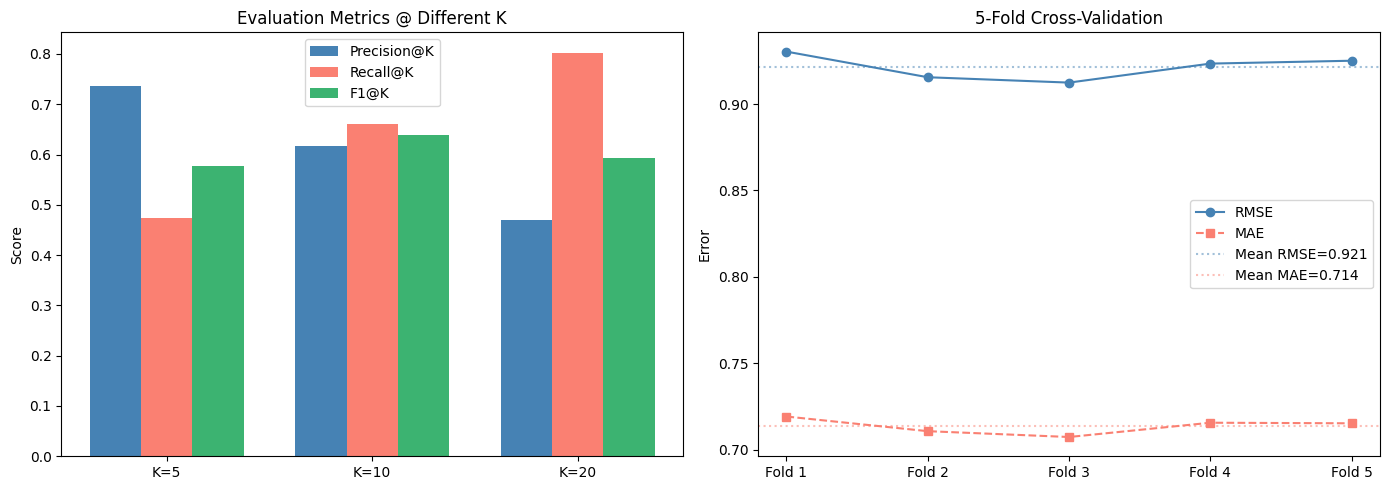

In [29]:
# Visualise results
ks    = [5, 10, 20]
precs = [precision_recall_f1_at_k(test_known, k)[0] for k in ks]
recs  = [precision_recall_f1_at_k(test_known, k)[1] for k in ks]
f1s   = [precision_recall_f1_at_k(test_known, k)[2] for k in ks]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Precision / Recall / F1 bars
x, w = np.arange(len(ks)), 0.25
ax1.bar(x - w, precs, w, label='Precision@K', color='steelblue')
ax1.bar(x,     recs,  w, label='Recall@K',    color='salmon')
ax1.bar(x + w, f1s,   w, label='F1@K',        color='mediumseagreen')
ax1.set_xticks(x)
ax1.set_xticklabels([f'K={k}' for k in ks])
ax1.set_ylabel('Score')
ax1.set_title('Evaluation Metrics @ Different K')
ax1.legend()

# CV fold line chart
folds = [f'Fold {i}' for i in range(1, 6)]
ax2.plot(folds, cv_rmse, 'o-',  label='RMSE', color='steelblue')
ax2.plot(folds, cv_mae,  's--', label='MAE',  color='salmon')
ax2.axhline(np.mean(cv_rmse), color='steelblue', linestyle=':', alpha=0.5,
            label=f'Mean RMSE={np.mean(cv_rmse):.3f}')
ax2.axhline(np.mean(cv_mae),  color='salmon',    linestyle=':', alpha=0.5,
            label=f'Mean MAE={np.mean(cv_mae):.3f}')
ax2.set_title('5-Fold Cross-Validation')
ax2.set_ylabel('Error')
ax2.legend()

plt.tight_layout()
plt.show()

In [30]:
os.makedirs('models', exist_ok=True)

# SVD artefacts (replaces Surprise's model file)
svd_artefacts = {
    'R_predicted':       R_predicted,
    'user2idx':          user2idx,
    'movie2idx':         movie2idx,
    'idx2movie':         idx2movie,
    'global_mean':       GLOBAL_MEAN,
    'rating_min':        rating_min,
    'rating_max':        rating_max,
}
with open('models/svd_artefacts.pkl', 'wb') as f:
    pickle.dump(svd_artefacts, f)

# Content-based artefacts
with open('models/cosine_sim.pkl', 'wb') as f:
    pickle.dump(cosine_sim, f)

movie_data.to_pickle('models/cb_data.pkl')
movies.to_pickle('models/movies.pkl')
ratings.to_pickle('models/ratings.pkl')

print('All models saved to models/ folder.')

All models saved to models/ folder.
